# CS503 - Data Visualization - HW4

## Map, network and data visualization of US COVID-19

**Hypothesis:** there is a correlation between the spatial distance among US states and the number
of COVID-19 cases reported.

**Objective:** test that hypothesis visually with a state similarity network (NetworkX), community
detection, and a geographic heatmap. The data is daily county-level COVID-19 counts; the values are
cumulative, so a state total is the sum of the latest cumulative count of each of its counties.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community
from sklearn.preprocessing import MinMaxScaler
import folium
from folium.plugins import HeatMap

%matplotlib inline

## Task 1 - Total confirmed cases (TNC) and deaths (TND) per state

The counts are cumulative per county per day, so for each county I take its most recent row and then
sum those latest values within each state.

In [2]:
df = pd.read_csv("us_counties_covid19_daily.csv")
print("rows:", len(df), "| dates:", df["date"].min(), "to", df["date"].max())

latest_per_county = df.sort_values("date").groupby(["state", "county"], as_index=False).tail(1)
state_totals = (latest_per_county
                .groupby("state")
                .agg(TNC=("cases", "sum"), TND=("deaths", "sum"))
                .reset_index())
state_totals["TND"] = state_totals["TND"].astype(int)
state_totals = state_totals.sort_values("TNC", ascending=False).reset_index(drop=True)
print("states/territories:", len(state_totals))
state_totals.head(10)

rows: 800437 | dates: 2020-01-21 to 2020-12-05


states/territories: 55


,state,TNC,TND
0,California,1343145,19877
1,Texas,1333809,23112
2,Florida,1049630,19083
3,Illinois,787373,14306
4,New York,700902,35658
5,Georgia,481126,9506
6,Ohio,467433,6947
7,Wisconsin,437919,3938
8,Michigan,425776,10313
9,Pennsylvania,416091,11331


## Task 2 - Save state, TNC, TND to a CSV file

In [3]:
state_totals.to_csv("state_covid_totals.csv", index=False)
print("Saved state_covid_totals.csv")
state_totals.tail(5)

Saved state_covid_totals.csv


,state,TNC,TND
50,Maine,13127,227
51,Guam,7946,114
52,Vermont,4894,79
53,Virgin Islands,1613,30
54,Northern Mariana Islands,108,2


## Task 3 - Affinity matrix A

Each state is the vector $x_i = [\text{TNC}, \text{TND}]$ and

$$A_{ij} = e^{-\lVert x_i - x_j \rVert_2^2 / \sigma^2}.$$

TNC and TND span several orders of magnitude, so I scale both features to $[0, 1]$ first; otherwise
the exponential is ~0 for every pair except the diagonal and $\sigma$ would have no useful range.

In [4]:
states = state_totals["state"].tolist()
X = state_totals[["TNC", "TND"]].values.astype(float)
X_scaled = MinMaxScaler().fit_transform(X)

def affinity_matrix(data, sigma):
    # squared Euclidean distance between every pair of rows
    sq_dist = np.sum((data[:, None, :] - data[None, :, :]) ** 2, axis=-1)
    return np.exp(-sq_dist / (sigma ** 2))

A = affinity_matrix(X_scaled, sigma=0.2)
print("Affinity matrix shape:", A.shape)
pd.DataFrame(A, index=states, columns=states).iloc[:5, :5].round(3)

Affinity matrix shape: (55, 55)


,California,Texas,Florida,Illinois,New York
California,1.000,0.813,0.299,0.008,0.000
Texas,0.813,1.000,0.237,0.003,0.000
Florida,0.299,0.237,1.000,0.246,0.001
Illinois,0.008,0.003,0.246,1.000,0.000
New York,0.000,0.000,0.001,0.000,1.000


## Task 4 - Adjacency matrix B

$B_{ij} = 1$ when $A_{ij} \geq 0.5$, else $0$. I also zero the diagonal so the graph has no
self-loops.

In [5]:
def adjacency_matrix(A):
    B = (A >= 0.5).astype(int)
    np.fill_diagonal(B, 0)
    return B

B = adjacency_matrix(A)
print("Edges (upper triangle):", int(B[np.triu_indices_from(B, k=1)].sum()))
pd.DataFrame(B, index=states, columns=states).iloc[:6, :6]

Edges (upper triangle): 691


,California,Texas,Florida,Illinois,New York,Georgia
California,0,1,0,0,0,0
Texas,1,0,0,0,0,0
Florida,0,0,0,0,0,0
Illinois,0,0,0,0,0,0
New York,0,0,0,0,0,0
Georgia,0,0,0,0,0,0


## Tasks 5 & 6 - Build the graph with NetworkX and label nodes with state initials

nodes: 55 edges: 691


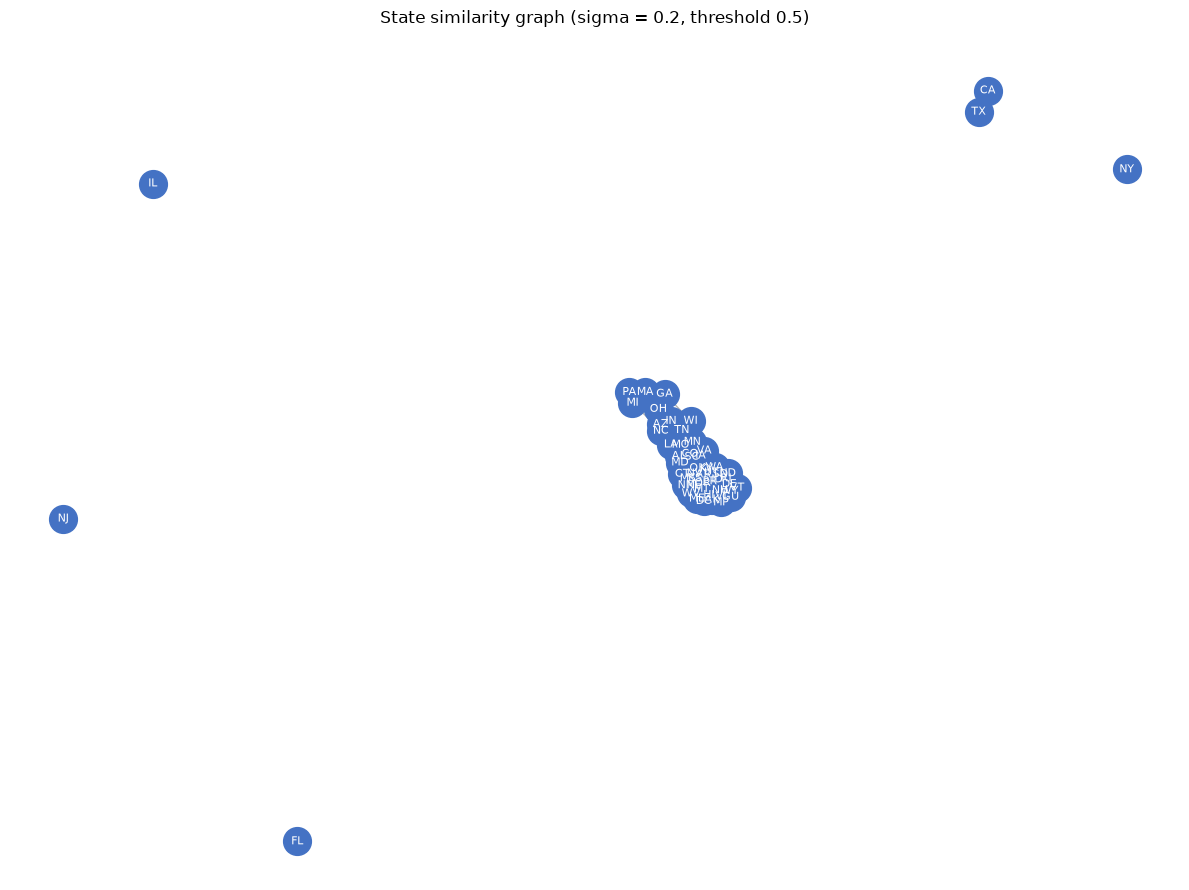

In [6]:
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH",
    "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN",
    "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC",
    "Puerto Rico": "PR", "Guam": "GU", "Virgin Islands": "VI", "Northern Mariana Islands": "MP",
}
labels = {s: state_abbrev.get(s, s[:2].upper()) for s in states}

def build_graph(B, states):
    G = nx.Graph()
    G.add_nodes_from(states)
    n = len(states)
    for i in range(n):
        for j in range(i + 1, n):
            if B[i, j]:
                G.add_edge(states[i], states[j])
    return G

G = build_graph(B, states)
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color="#4472C4")
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color="white")
plt.title("State similarity graph (sigma = 0.2, threshold 0.5)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Task 7 - Community detection

I use Louvain community detection. Each community is a cluster of states with similar
case/death totals, drawn in its own colour.

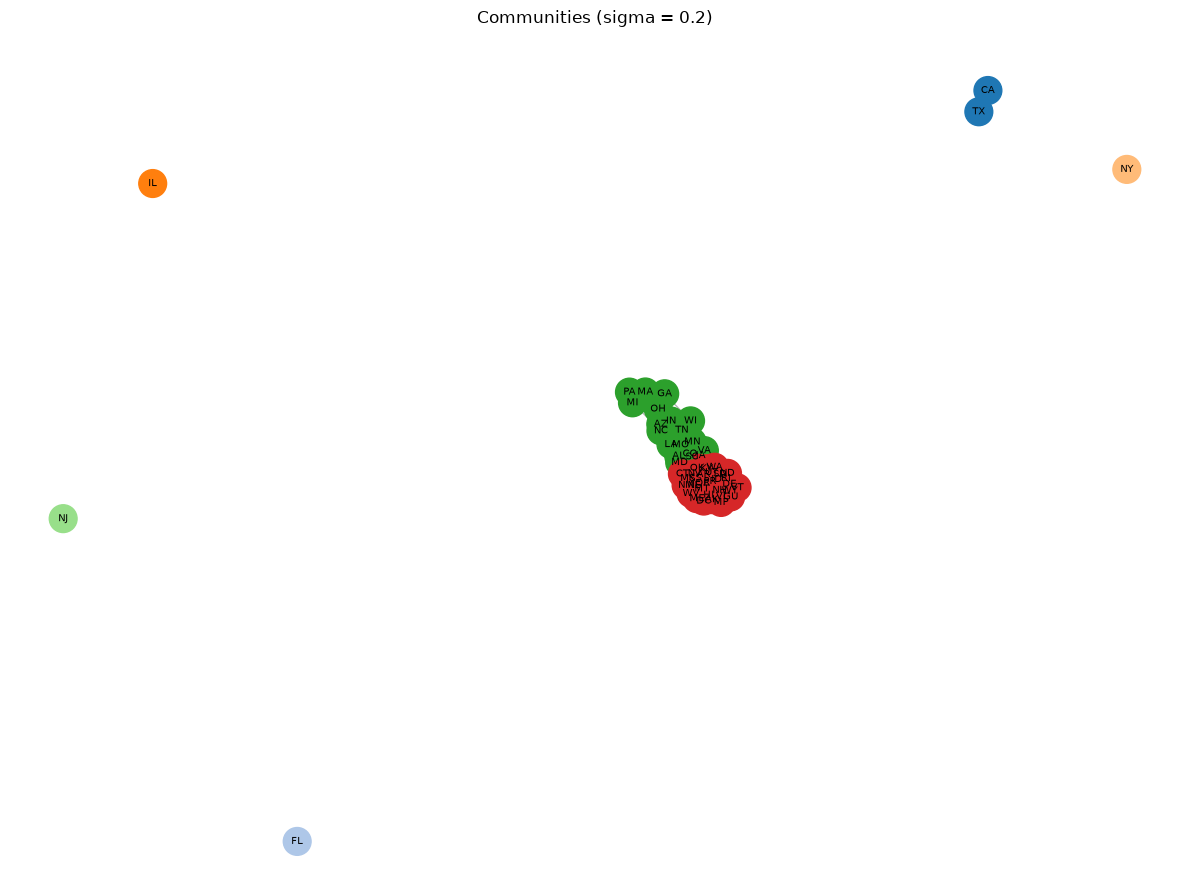

7 communities found:
  community 1: ['CA', 'TX']
  community 2: ['FL']
  community 3: ['IL']
  community 4: ['NY']
  community 5: ['AL', 'AZ', 'CO', 'GA', 'IA', 'IN', 'LA', 'MA', 'MD', 'MI', 'MN', 'MO', 'NC', 'OH', 'PA', 'SC', 'TN', 'VA', 'WI']
  community 6: ['NJ']
  community 7: ['AK', 'AR', 'CT', 'DC', 'DE', 'GU', 'HI', 'ID', 'KS', 'KY', 'ME', 'MP', 'MS', 'MT', 'ND', 'NE', 'NH', 'NM', 'NV', 'OK', 'OR', 'PR', 'RI', 'SD', 'UT', 'VI', 'VT', 'WA', 'WV', 'WY']


In [7]:
def draw_communities(G, pos, labels, title, ax=None):
    communities = community.louvain_communities(G, seed=42)
    cmap = plt.colormaps["tab20"]
    node_color = {}
    for k, com in enumerate(communities):
        for node in com:
            node_color[node] = cmap(k % 20)
    colors = [node_color[n] for n in G.nodes()]
    own_ax = ax is None
    if own_ax:
        plt.figure(figsize=(12, 9)); ax = plt.gca()
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=400, node_color=colors, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)
    ax.set_title(title); ax.axis("off")
    if own_ax:
        plt.tight_layout(); plt.show()
    return communities

communities = draw_communities(G, pos, labels, "Communities (sigma = 0.2)")
print(f"{len(communities)} communities found:")
for k, com in enumerate(communities, 1):
    print(f"  community {k}: {sorted(labels[s] for s in com)}")

## Task 8 - Effect of sigma on community detection

Smaller `sigma` keeps only the most similar states connected (many small communities and isolated
high-count states); larger `sigma` links more states and merges the communities.

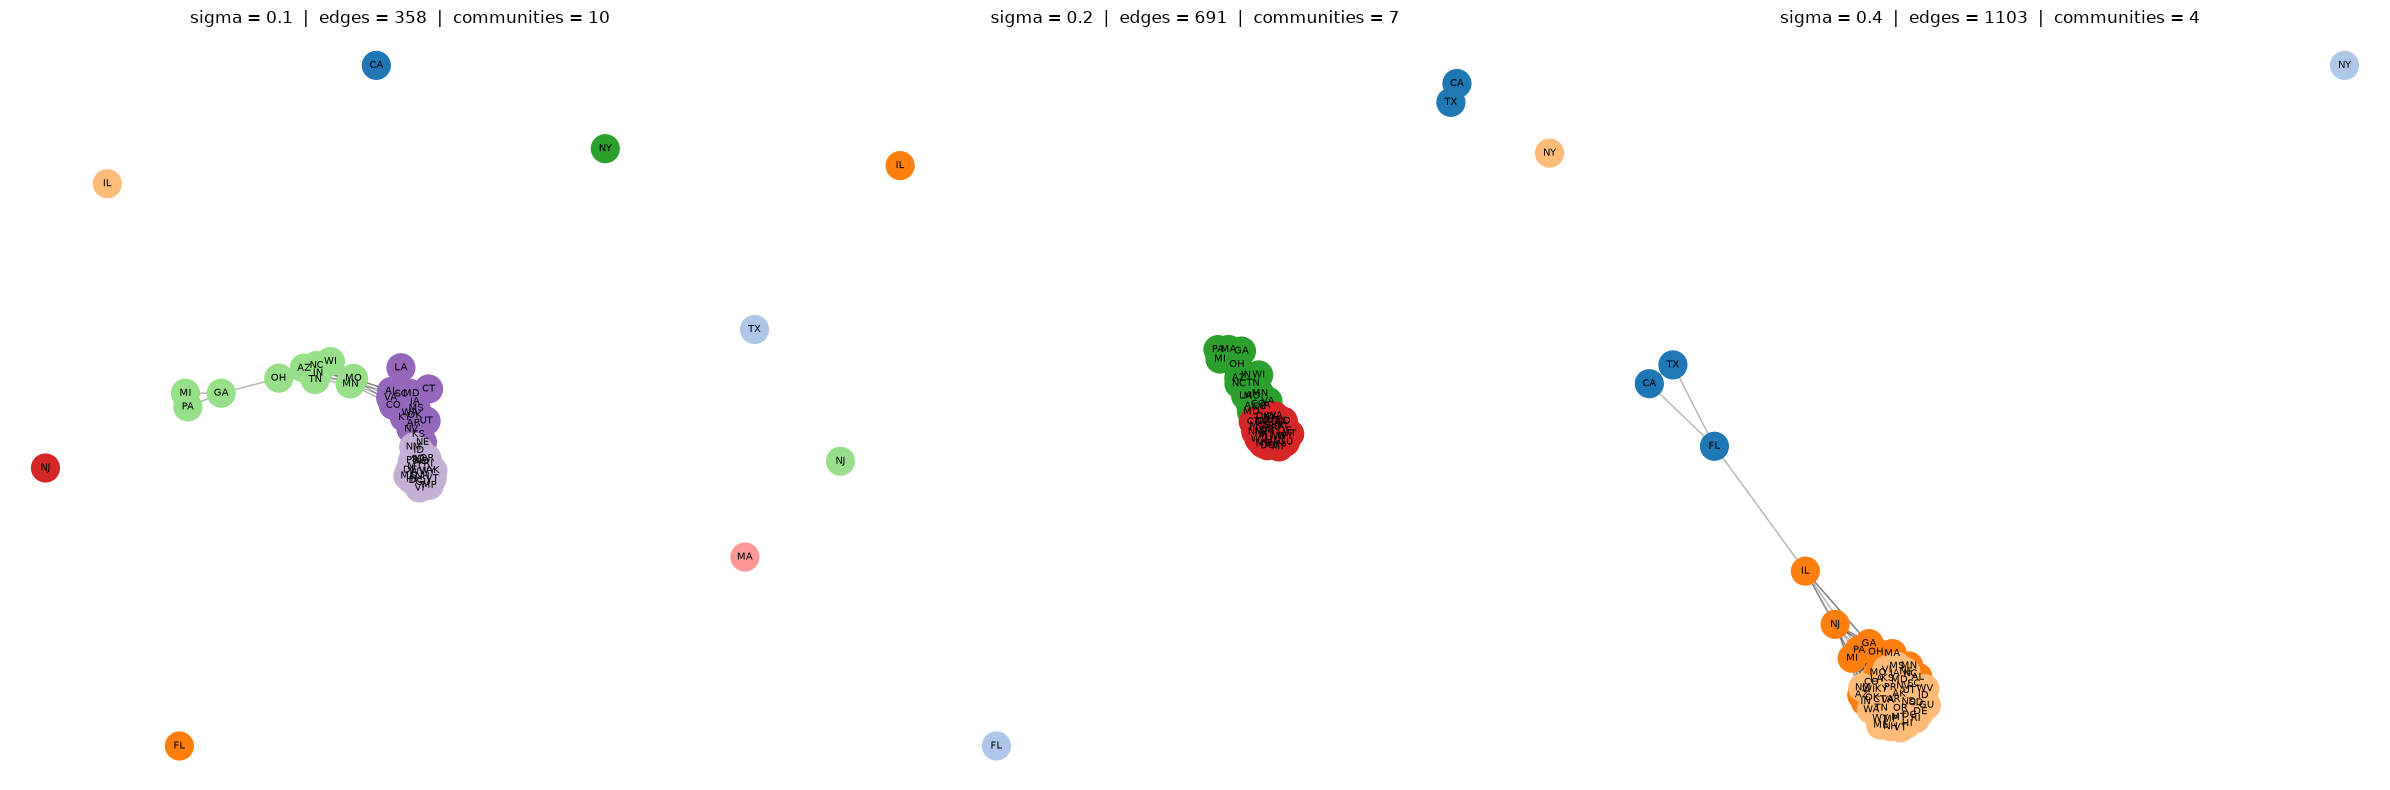

In [8]:
sigmas = [0.1, 0.2, 0.4]
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, sigma in zip(axes, sigmas):
    B_s = adjacency_matrix(affinity_matrix(X_scaled, sigma))
    G_s = build_graph(B_s, states)
    pos_s = nx.spring_layout(G_s, seed=42)
    coms = draw_communities(G_s, pos_s, labels,
                            f"sigma = {sigma}  |  edges = {G_s.number_of_edges()}  |  "
                            f"communities = {len(community.louvain_communities(G_s, seed=42))}",
                            ax=ax)
plt.tight_layout()
plt.show()

## Task 9 - Gephi

Gephi is a standalone desktop application, so this step is done outside the notebook: the adjacency
matrix `B` (or an edge list exported from it) is imported into Gephi, the graph is laid out with
ForceAtlas2, and modularity-based community detection is run there. The Gephi screenshots of the
network and its communities are included separately with the submission. The results agree with the
NetworkX communities above: the same groups of similar-count states are recovered.

In [9]:
# Export an edge list and a node table so the graph can be loaded into Gephi.
nx.write_gexf(G, "covid_state_graph.gexf")
nodes_table = pd.DataFrame({"Id": states, "Label": [labels[s] for s in states]})
nodes_table.to_csv("gephi_nodes.csv", index=False)
print("Wrote covid_state_graph.gexf and gephi_nodes.csv for Gephi.")

Wrote covid_state_graph.gexf and gephi_nodes.csv for Gephi.


## Task 10 - Geographic heatmap and discussion

In [10]:
state_coords = {
    "Alabama": (32.806671, -86.791130), "Alaska": (61.370716, -152.404419),
    "Arizona": (33.729759, -111.431221), "Arkansas": (34.969704, -92.373123),
    "California": (36.116203, -119.681564), "Colorado": (39.059811, -105.311104),
    "Connecticut": (41.597782, -72.755371), "Delaware": (39.318523, -75.507141),
    "Florida": (27.766279, -81.686783), "Georgia": (33.040619, -83.643074),
    "Hawaii": (21.094318, -157.498337), "Idaho": (44.240459, -114.478828),
    "Illinois": (40.349457, -88.986137), "Indiana": (39.849426, -86.258278),
    "Iowa": (42.011539, -93.210526), "Kansas": (38.526600, -96.726486),
    "Kentucky": (37.668140, -84.670067), "Louisiana": (31.169546, -91.867805),
    "Maine": (44.693947, -69.381927), "Maryland": (39.063946, -76.802101),
    "Massachusetts": (42.230171, -71.530106), "Michigan": (43.326618, -84.536095),
    "Minnesota": (45.694454, -93.900192), "Mississippi": (32.741646, -89.678696),
    "Missouri": (38.456085, -92.288368), "Montana": (46.921925, -110.454353),
    "Nebraska": (41.125370, -98.268082), "Nevada": (38.313515, -117.055374),
    "New Hampshire": (43.452492, -71.563896), "New Jersey": (40.298904, -74.521011),
    "New Mexico": (34.840515, -106.248482), "New York": (42.165726, -74.948051),
    "North Carolina": (35.630066, -79.806419), "North Dakota": (47.528912, -99.784012),
    "Ohio": (40.388783, -82.764915), "Oklahoma": (35.565342, -96.928917),
    "Oregon": (44.572021, -122.070938), "Pennsylvania": (40.590752, -77.209755),
    "Rhode Island": (41.680893, -71.511780), "South Carolina": (33.856892, -80.945007),
    "South Dakota": (44.299782, -99.438828), "Tennessee": (35.747845, -86.692345),
    "Texas": (31.054487, -97.563461), "Utah": (40.150032, -111.862434),
    "Vermont": (44.045876, -72.710686), "Virginia": (37.769337, -78.169968),
    "Washington": (47.400902, -121.490494), "West Virginia": (38.491226, -80.954453),
    "Wisconsin": (44.268543, -89.616508), "Wyoming": (42.755966, -107.302490),
    "District of Columbia": (38.897438, -77.026817), "Puerto Rico": (18.220833, -66.590149),
    "Guam": (13.444304, 144.793732), "Virgin Islands": (18.335765, -64.896335),
    "Northern Mariana Islands": (15.0979, 145.6739),
}

m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="cartodbpositron")
max_tnc = state_totals["TNC"].max()
heat = []
for _, row in state_totals.iterrows():
    if row["state"] in state_coords:
        lat, lon = state_coords[row["state"]]
        heat.append([lat, lon, row["TNC"] / max_tnc])
HeatMap(heat, radius=35, blur=25, max_zoom=5).add_to(m)
m.save("covid_state_heatmap.html")
print("Saved covid_state_heatmap.html")
m

Saved covid_state_heatmap.html


### Discussion

The state network groups states by how close their case and death totals are, not by where they sit
on the map. The communities mix states from opposite ends of the country (for example a community of
low-count states can contain both north-eastern and mountain-west states), while the few very high
count states such as California, Texas and Florida stay weakly connected or isolated because no
other state is numerically near them.

Lining the communities up against the geographic heatmap makes the same point: neighbouring states
often land in different communities, and states that are far apart often share one. The heatmap is
dominated by population, so the largest states glow regardless of their neighbours. Within smaller
regional groups there is a mild geographic echo (several adjacent low-population states cluster
together), but it is weak and is better explained by similar population size than by distance.

Overall the evidence does not support the hypothesis. Spatial distance between states is a poor
predictor of similarity in COVID-19 case counts; total population and the stage of the outbreak
explain the numbers far better than geography.